# 🇮🇩 Food Commodity Price Analysis & Forecasting Across Indonesian Provinces

**Portfolio Project — Data Science for Indonesian Use Cases**

This notebook is **generic/reusable** — built to analyze food commodity price data per province
from sources such as PIHPS/BPS (Indonesia's national price monitoring bodies), which all follow
the same template regardless of commodity (rice, chili, onion, cooking oil, sugar, etc.).

**To reuse for another commodity:** just change 2 variables in the **configuration** cell
(Section 0) — `FILE_PATH` and `COMMODITY_NAME` — then Run All. All titles, chart labels, and
analysis will adapt automatically.

**Analysis goals:**
1. Understand the national price trend and regional price disparity
2. Identify the most stable vs. most volatile provinces
3. Segment provinces by price pattern (clustering)
4. Produce a simple short-term price forecast
5. Surface insights relevant to food security policy


## 📌 Problem Statement

Indonesia is an archipelago of 17,000+ islands with 34 provinces spread across vastly different
production zones, logistics networks, and consumption patterns. Rice — the national staple food —
is a politically and economically sensitive commodity: price spikes directly affect inflation
figures, household purchasing power, and food security policy (Bulog stock releases, market
operations, import decisions).

**The core problem:** price monitoring data is published province-by-province, month-by-month, in
a raw spreadsheet format that is not immediately actionable. Policymakers, analysts, and
researchers need answers to concrete questions such as:

- Is the national rice price trending up or down, and how fast?
- Which provinces consistently pay more than others, and by how much — is this explained by
  known factors like inter-island logistics, or does it warrant closer investigation?
- Which provinces show the most erratic (volatile) price swings — a signal of potential
  supply instability that may need market intervention?
- Can provinces be grouped into meaningful segments (e.g. consistently cheap / consistently
  expensive / fast-rising) to prioritize where stabilization efforts should focus?
- Based on the trend so far, what should we expect next month if no intervention happens?

**Why this matters:** rice price volatility has historically been linked to social unrest and is
one of the most closely watched indicators by Indonesia's central bank (Bank Indonesia) and
statistics agency (BPS) when assessing inflation risk. A lightweight, reusable analysis pipeline
that can be pointed at *any* commodity's price file (not just rice) makes this kind of monitoring
scalable across the dozens of commodities tracked by PIHPS.

**What this project delivers:** an end-to-end, reusable notebook that turns a raw monthly
province-level price file into cleaned data, exploratory analysis, province segmentation, and a
short-term forecast — answering the questions above for any commodity that follows the same data
template.


## 0. ⚙️ Configuration

**Change these two lines to analyze a different commodity** (chili, onion, cooking oil, etc.) —
as long as the file follows the same column template (`No`, `Komoditas (Rp)`, then date
columns).

In [1]:
# ============== CHANGE HERE FOR A DIFFERENT COMMODITY ==============
FILE_PATH = 'data/rice.xlsx'
COMMODITY_NAME = 'Rice'
UNIT = 'IDR/kg'
# =====================================================================


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import os

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

pd.set_option('display.max_rows', 40)

OUTPUT_DIR = f"output/{COMMODITY_NAME.lower().replace(' ', '_')}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Analyzing commodity: {COMMODITY_NAME}")
print(f"Output will be saved to: {OUTPUT_DIR}/")


Analyzing commodity: Rice
Output will be saved to: output/rice/


## 1. Data Loading & Cleaning

The cleaning function is written generically — it accepts any commodity file as long as the
format is consistent with the template (wide format, prices as strings with thousands
separators).

In [3]:
def load_and_clean(file_path):
    """Cleans a PIHPS/BPS-format commodity price file into an analysis-ready DataFrame.

    Robust to two common variations in Indonesian government data:
    - Short time range (a few months) OR long time range (multi-year)
    - Empty cells marked as '-' (data not yet available for that province/month) -> becomes NaN
    """
    raw = pd.read_excel(file_path)
    df = raw.rename(columns={'Komoditas (Rp)': 'Province'}).drop(columns=['No'])

    date_cols_raw = [c for c in df.columns if c != 'Province']
    rename_map = {}
    for c in date_cols_raw:
        d, m, y = c.replace(' ', '').split('/')
        rename_map[c] = f"{y}-{m}-01"
    df = df.rename(columns=rename_map)

    for c in rename_map.values():
        cleaned = df[c].astype(str).str.replace(',', '', regex=False).str.strip()
        cleaned = cleaned.replace({'-': np.nan, '': np.nan, 'nan': np.nan})
        df[c] = pd.to_numeric(cleaned, errors='coerce')

    date_cols = list(rename_map.values())
    return df, date_cols


df, date_cols = load_and_clean(FILE_PATH)
n_missing = df[date_cols].isna().sum().sum()
print(f"Number of monthly observations: {len(date_cols)}  |  Range: {date_cols[0]} to {date_cols[-1]}")
print(f"Missing values detected & handled as NaN: {n_missing}")
print(df.shape)
df.head()


Number of monthly observations: 7  |  Range: 2026-01-01 to 2026-07-01
Missing values detected & handled as NaN: 0
(35, 8)


,Province,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01,2026-07-01
0,Semua Provinsi,15750,15750,15800,15900,15950,16000,16150
1,Aceh,15100,15350,15250,15200,15150,15150,15350
2,Sumatera Utara,15100,15050,14800,14850,14800,14900,15150
3,Sumatera Barat,18200,18250,18250,18150,18150,17850,17800
4,Riau,16350,16350,16400,16400,16450,16450,16450


In [4]:
# Separate the national aggregate row from per-province data
national = df[df['Province'] == 'Semua Provinsi'].copy()
national['Province'] = 'All Provinces'
prov_df = df[df['Province'] != 'Semua Provinsi'].copy().reset_index(drop=True)

# Build long format for time series analysis & plotting
long_df = prov_df.melt(id_vars='Province', var_name='Date', value_name='Price')
long_df['Date'] = pd.to_datetime(long_df['Date'])
long_df = long_df.sort_values(['Province', 'Date']).reset_index(drop=True)

national_long = national.melt(id_vars='Province', var_name='Date', value_name='Price')
national_long['Date'] = pd.to_datetime(national_long['Date'])

print(f"Commodity        : {COMMODITY_NAME}")
print(f"Number of provinces : {prov_df['Province'].nunique()}")
print(f"Time range           : {long_df['Date'].min().date()} to {long_df['Date'].max().date()}")
long_df.head()


Commodity        : Rice
Number of provinces : 34
Time range           : 2026-01-01 to 2026-07-01


,Province,Date,Price
0,Aceh,2026-01-01,15100
1,Aceh,2026-02-01,15350
2,Aceh,2026-03-01,15250
3,Aceh,2026-04-01,15200
4,Aceh,2026-05-01,15150


## 2. National Price Trend

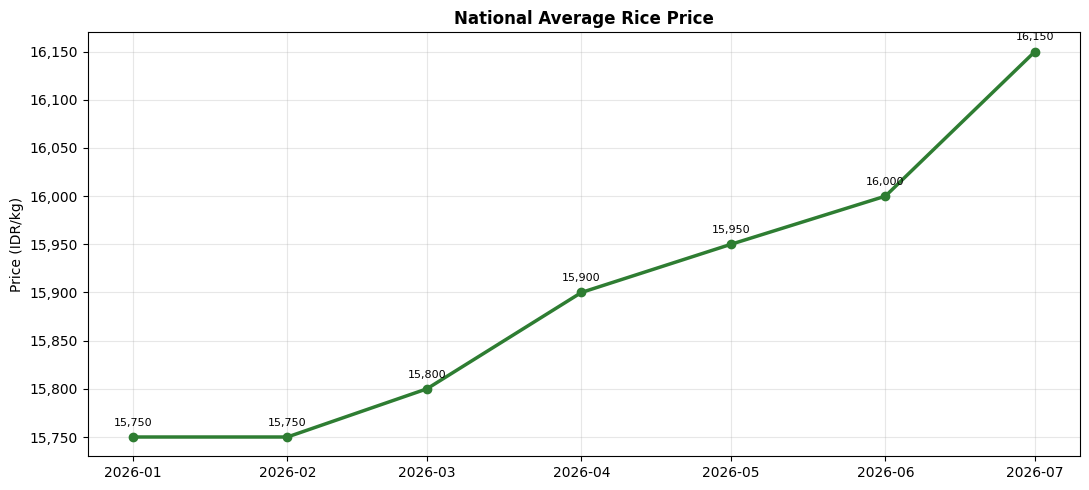

In [5]:
fig, ax = plt.subplots()
ax.plot(national_long['Date'], national_long['Price'], marker='o', linewidth=2.5, color='#2E7D32')
ax.set_title(f'National Average {COMMODITY_NAME} Price', fontweight='bold')
ax.set_ylabel(f'Price ({UNIT})')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
for x, y in zip(national_long['Date'], national_long['Price']):
    ax.annotate(f'{y:,.0f}', (x, y), textcoords="offset points", xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_national_trend.png', dpi=120)
plt.show()


In [6]:
change = national_long['Price'].iloc[-1] - national_long['Price'].iloc[0]
pct = change / national_long['Price'].iloc[0] * 100
direction = 'increased' if change > 0 else 'decreased'
print(f"National {COMMODITY_NAME} price {direction} from IDR{national_long['Price'].iloc[0]:,.0f} to IDR{national_long['Price'].iloc[-1]:,.0f}")
print(f"Change: IDR{change:,.0f} ({pct:.2f}%) over the observed period")


National Rice price increased from IDR15,750 to IDR16,150
Change: IDR400 (2.54%) over the observed period


## 3. Regional Price Disparity

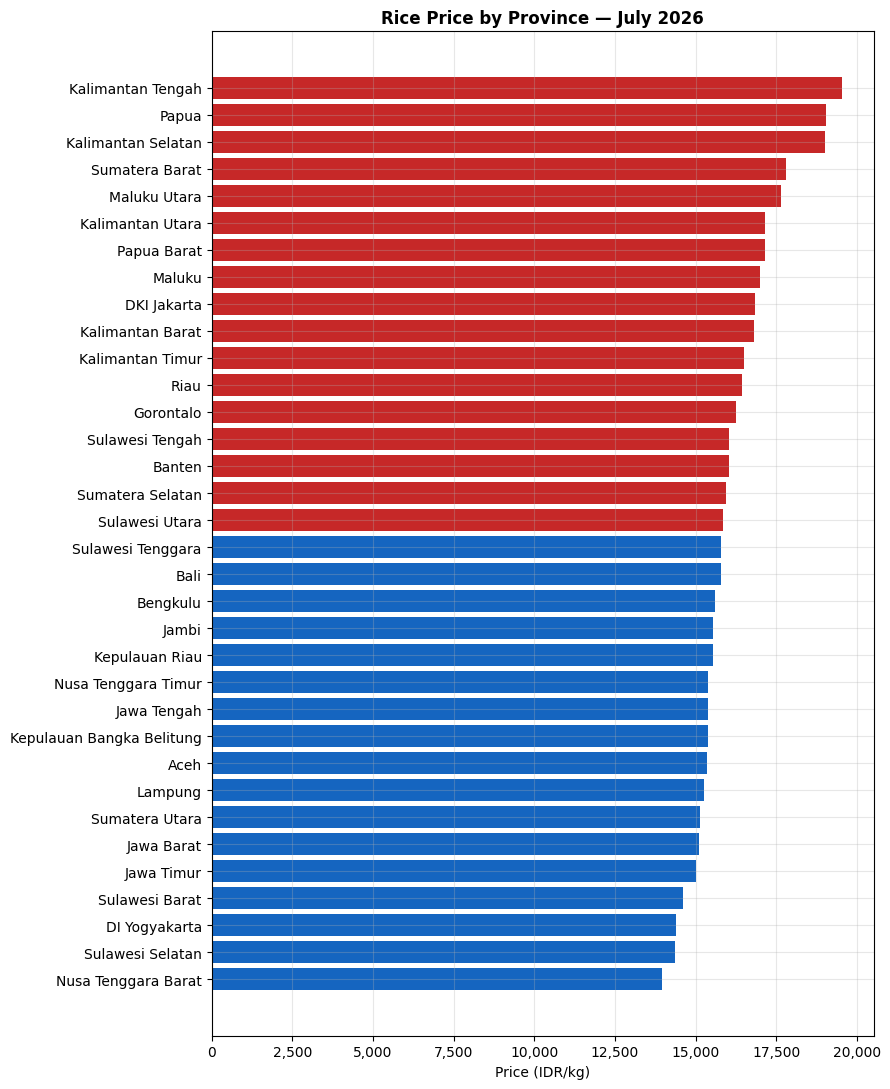

Top 5 Most Expensive Provinces:
          Province  Latest_Price
 Kalimantan Tengah         19550
             Papua         19050
Kalimantan Selatan         19000
    Sumatera Barat         17800
      Maluku Utara         17650

Top 5 Cheapest Provinces:
           Province  Latest_Price
         Jawa Timur         15000
     Sulawesi Barat         14600
      DI Yogyakarta         14400
   Sulawesi Selatan         14350
Nusa Tenggara Barat         13950


In [7]:
latest_month = date_cols[-1]
latest = prov_df[['Province', latest_month]].rename(columns={latest_month: 'Latest_Price'})
latest = latest.sort_values('Latest_Price', ascending=False)

fig, ax = plt.subplots(figsize=(9, 11))
colors = ['#C62828' if v > latest['Latest_Price'].median() else '#1565C0' for v in latest['Latest_Price']]
ax.barh(latest['Province'], latest['Latest_Price'], color=colors)
ax.invert_yaxis()
ax.set_title(f'{COMMODITY_NAME} Price by Province — {pd.to_datetime(latest_month).strftime("%B %Y")}', fontweight='bold')
ax.set_xlabel(f'Price ({UNIT})')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_price_by_province_latest.png', dpi=120)
plt.show()

print("Top 5 Most Expensive Provinces:")
print(latest.head(5).to_string(index=False))
print("\nTop 5 Cheapest Provinces:")
print(latest.tail(5).to_string(index=False))


In [8]:
gap = latest['Latest_Price'].max() - latest['Latest_Price'].min()
gap_pct = gap / latest['Latest_Price'].min() * 100
print(f"Highest-lowest price gap: IDR{gap:,.0f} ({gap_pct:.1f}% more expensive)")
print(f"Most expensive : {latest.iloc[0]['Province']} (IDR{latest.iloc[0]['Latest_Price']:,.0f})")
print(f"Cheapest       : {latest.iloc[-1]['Province']} (IDR{latest.iloc[-1]['Latest_Price']:,.0f})")


Highest-lowest price gap: IDR5,600 (40.1% more expensive)
Most expensive : Kalimantan Tengah (IDR19,550)
Cheapest       : Nusa Tenggara Barat (IDR13,950)


## 4. Price Volatility by Province

In [9]:
volatility = long_df.groupby('Province')['Price'].agg(['mean', 'std', 'min', 'max'])
volatility['range'] = volatility['max'] - volatility['min']
volatility['cv_pct'] = (volatility['std'] / volatility['mean'] * 100).round(2)
volatility = volatility.sort_values('cv_pct', ascending=False)

print("Top 5 Most Volatile Provinces (highest coefficient of variation):")
print(volatility.head(5)[['mean', 'std', 'range', 'cv_pct']].round(0).to_string())

print("\nTop 5 Most Stable Provinces:")
print(volatility.tail(5)[['mean', 'std', 'range', 'cv_pct']].round(0).to_string())


Top 5 Most Volatile Provinces (highest coefficient of variation):
                       mean    std  range  cv_pct
Province                                         
Kalimantan Tengah   18643.0  755.0   1700     4.0
Kalimantan Selatan  18300.0  599.0   1450     3.0
Gorontalo           15343.0  418.0   1200     3.0
Banten              15450.0  406.0   1100     3.0
Sulawesi Utara      15107.0  331.0    950     2.0

Top 5 Most Stable Provinces:
                        mean   std  range  cv_pct
Province                                         
Kepulauan Riau       15479.0  70.0    200     0.0
Sulawesi Selatan     14264.0  48.0    150     0.0
Nusa Tenggara Barat  13907.0  45.0    100     0.0
Nusa Tenggara Timur  15314.0  48.0    150     0.0
Riau                 16407.0  45.0    100     0.0


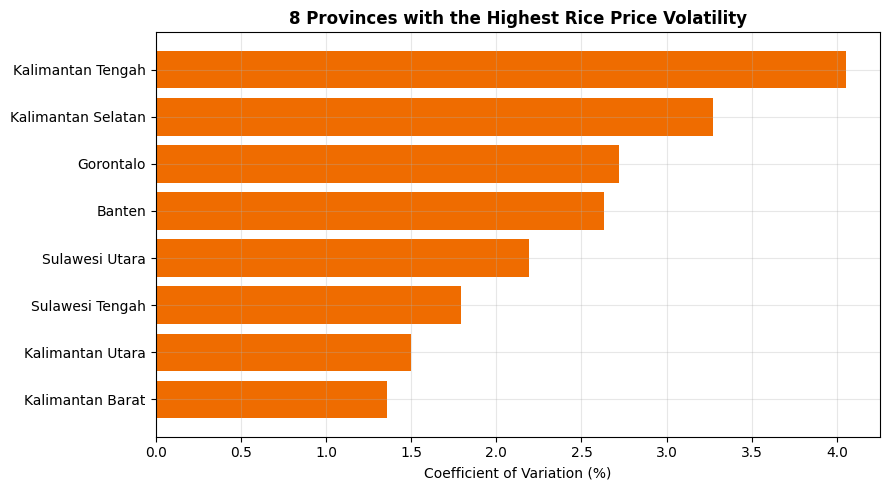

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
top_volatile = volatility.head(8).sort_values('cv_pct')
ax.barh(top_volatile.index, top_volatile['cv_pct'], color='#EF6C00')
ax.set_title(f'8 Provinces with the Highest {COMMODITY_NAME} Price Volatility', fontweight='bold')
ax.set_xlabel('Coefficient of Variation (%)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/03_province_volatility.png', dpi=120)
plt.show()


## 5. Province Segmentation (Clustering)

In [11]:
X_feat = []
provinces = prov_df['Province'].tolist()
months = np.arange(len(date_cols))

for _, row in prov_df.iterrows():
    prices = row[date_cols].values.astype(float)
    mask = ~np.isnan(prices)  # ignore months with missing data
    slope = np.polyfit(months[mask], prices[mask], 1)[0] if mask.sum() >= 2 else 0.0
    X_feat.append([np.nanmean(prices), slope])

feat_df = pd.DataFrame(X_feat, columns=['avg_price', 'monthly_trend'], index=provinces)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
feat_df['cluster'] = kmeans.fit_predict(X_scaled)

label_map = feat_df.groupby('cluster')['avg_price'].mean().sort_values().index
names_map = {label_map[0]: 'Low Price', label_map[1]: 'Mid Price', label_map[2]: 'High Price'}
feat_df['segment'] = feat_df['cluster'].map(names_map)

feat_df.sort_values('avg_price')


,avg_price,monthly_trend,cluster,segment
Nusa Tenggara Barat,13907.142857,17.857143,2,Low Price
DI Yogyakarta,14228.571429,21.428571,2,Low Price
Sulawesi Selatan,14264.285714,17.857143,2,Low Price
Sulawesi Barat,14442.857143,50.000000,2,Low Price
Jawa Timur,14721.428571,69.642857,2,Low Price
Lampung,14885.714286,73.214286,2,Low Price
Sumatera Utara,14950.000000,-5.357143,2,Low Price
Jawa Barat,15021.428571,60.714286,2,Low Price
Sulawesi Utara,15107.142857,92.857143,2,Low Price
Aceh,15221.428571,8.928571,2,Low Price


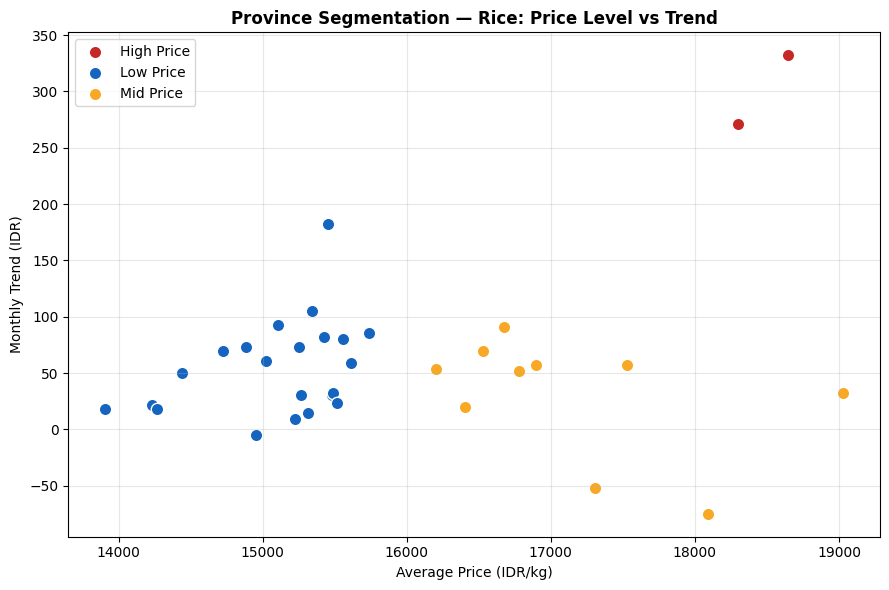


Low Price (22 provinces):
Aceh, Sumatera Utara, Kepulauan Riau, Jambi, Bengkulu, Sumatera Selatan, Kepulauan Bangka Belitung, Lampung, Banten, Jawa Barat, Jawa Tengah, DI Yogyakarta, Jawa Timur, Bali, Nusa Tenggara Barat, Nusa Tenggara Timur, Gorontalo, Sulawesi Selatan, Sulawesi Tenggara, Sulawesi Tengah, Sulawesi Utara, Sulawesi Barat

Mid Price (10 provinces):
Sumatera Barat, Riau, DKI Jakarta, Kalimantan Barat, Kalimantan Timur, Kalimantan Utara, Maluku, Maluku Utara, Papua, Papua Barat

High Price (2 provinces):
Kalimantan Selatan, Kalimantan Tengah


In [12]:
fig, ax = plt.subplots(figsize=(9, 6))
colors_map = {'Low Price': '#1565C0', 'Mid Price': '#F9A825', 'High Price': '#C62828'}
for seg, group in feat_df.groupby('segment'):
    ax.scatter(group['avg_price'], group['monthly_trend'], label=seg, s=80, color=colors_map[seg], edgecolor='white')
ax.set_xlabel(f'Average Price ({UNIT})')
ax.set_ylabel('Monthly Trend (IDR)')
ax.set_title(f'Province Segmentation — {COMMODITY_NAME}: Price Level vs Trend', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_province_segmentation.png', dpi=120)
plt.show()

for seg in ['Low Price', 'Mid Price', 'High Price']:
    members = feat_df[feat_df['segment'] == seg].index.tolist()
    print(f"\n{seg} ({len(members)} provinces):")
    print(', '.join(members))


## 6. Next-Month Price Forecast

> **Methodology note:** The dataset has a limited number of monthly data points, so complex
> time series models (ARIMA, Prophet) risk overfitting. The approach used here is a **simple
> linear regression** per province to extrapolate the short-term trend. This forecast is
> indicative, not a high-precision prediction. For datasets with longer history (24+ months),
> a seasonal model (SARIMA/Prophet) would be more appropriate.

In [13]:
forecast_month_idx = len(date_cols)
forecasts = {}

for prov in provinces:
    prices = prov_df[prov_df['Province'] == prov][date_cols].values.flatten().astype(float)
    mask = ~np.isnan(prices)
    if mask.sum() < 2:
        forecasts[prov] = np.nan
        continue
    model = LinearRegression()
    model.fit(months[mask].reshape(-1, 1), prices[mask])
    pred = model.predict([[forecast_month_idx]])[0]
    forecasts[prov] = pred

forecast_df = pd.DataFrame.from_dict(forecasts, orient='index', columns=['Forecast_NextMonth'])
forecast_df['Latest_Price'] = prov_df.set_index('Province')[latest_month]
forecast_df['Change'] = forecast_df['Forecast_NextMonth'] - forecast_df['Latest_Price']
forecast_df = forecast_df.sort_values('Change', ascending=False)

print("Top 5 provinces with the fastest projected increase:")
print(forecast_df.head(5).round(0).to_string())


Top 5 provinces with the fastest projected increase:
                    Forecast_NextMonth  Latest_Price  Change
Kalimantan Tengah              19971.0         19550   421.0
Kalimantan Selatan             19386.0         19000   386.0
DKI Jakarta                    17036.0         16850   186.0
Jawa Barat                     15264.0         15100   164.0
Jawa Tengah                    15543.0         15400   143.0


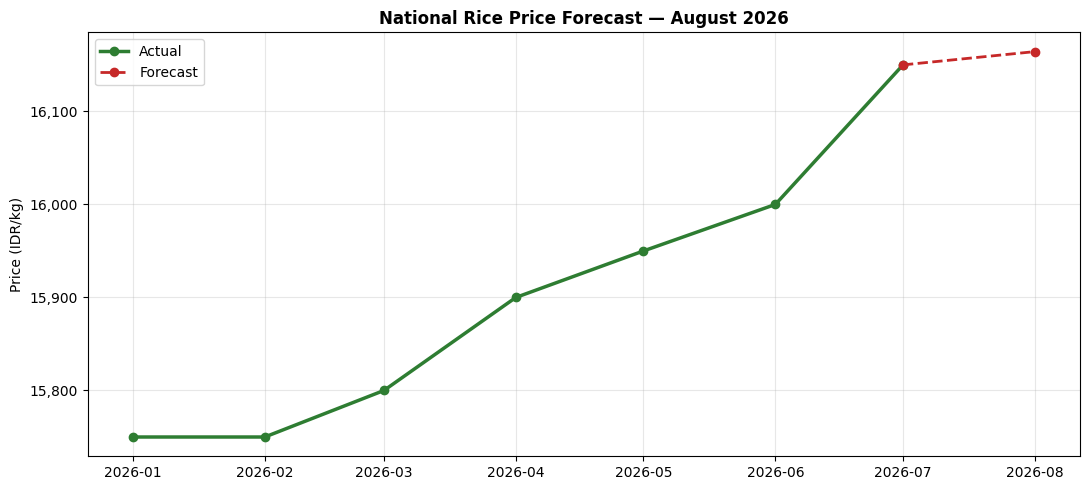

National price forecast for August 2026: IDR16,164 (previous month: IDR16,150)


In [14]:
nat_prices = national_long['Price'].values
nat_model = LinearRegression()
nat_model.fit(months.reshape(-1, 1), nat_prices)
nat_pred = nat_model.predict([[forecast_month_idx]])[0]

forecast_month_date = pd.to_datetime(latest_month) + pd.DateOffset(months=1)

fig, ax = plt.subplots()
ax.plot(national_long['Date'], nat_prices, marker='o', color='#2E7D32', linewidth=2.5, label='Actual')
ax.plot([national_long['Date'].iloc[-1], forecast_month_date],
        [nat_prices[-1], nat_pred], marker='o', color='#C62828', linestyle='--', linewidth=2, label='Forecast')
ax.set_title(f'National {COMMODITY_NAME} Price Forecast — {forecast_month_date.strftime("%B %Y")}', fontweight='bold')
ax.set_ylabel(f'Price ({UNIT})')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_national_forecast.png', dpi=120)
plt.show()

print(f"National price forecast for {forecast_month_date.strftime('%B %Y')}: IDR{nat_pred:,.0f} (previous month: IDR{nat_prices[-1]:,.0f})")


## 7. Summary & Recommendations

**Summary template** (fill in based on the actual commodity analyzed):

1. Direction of the national price trend over the observed period
2. Provinces with the largest price disparity & likely drivers (logistics, local production)
3. Most volatile provinces — candidates for market intervention/price stabilization
4. Projected price direction for next month

**Limitations (apply to any commodity using this template):**
- Limited number of monthly data points → not enough to capture complex seasonal patterns
- Single-commodity analysis; richer insights would come from combining multiple commodities
- Linear forecasts assume the trend continues, and don't account for government intervention

**Further development:**
- Run this notebook for multiple commodities (chili, onion, cooking oil) and compare
- Combine results into a single dashboard (Streamlit) with a commodity dropdown
- Add rainfall/production data for causal analysis
